# Introduction to Machine Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Distinguish supervised, unsupervised, and reinforcement learning
- Match problem types to ML paradigms

## 🔗 Where this fits

**Builds on:** Unit 2, lesson 04 "Probabilistic Reasoning: Bayes' Theorem" — updating beliefs from evidence is exactly what learning from data does.

**Used later in:** Course 04 (AIAT 114) — the whole course, which is these three paradigms turned into working algorithms.

---


## 🎯 A $1,000,000 model that was never switched on

In October 2006 Netflix released 100 million real ratings and offered **$1
million** to anyone who could beat its own recommender by 10% on prediction
error. Three years later, in September 2009, the team *BellKor's Pragmatic Chaos*
crossed the line with a **10.06%** improvement and collected the prize.

Netflix never deployed the winning solution. It was an ensemble of more than a
hundred models — built for 100 million ratings when Netflix already had billions,
built as a static fit when the real system needed to update as members rated, and
built for DVD-by-post at the moment the business was moving to streaming. Netflix
took the two strongest individual models, engineered those into production, and
left the rest of the prize-winning ensemble on the shelf. The company said as much
publicly.

Keep both halves. The competition genuinely advanced the field — matrix
factorisation and ensembling came out of it. And the best model on the leaderboard
was not the best model for the product. **"Highest score" and "should be deployed"
are different questions**, and this diploma will keep separating them.

### What goes wrong without the supervised / unsupervised / reinforcement split

Reaching for the wrong paradigm wastes the expensive resource. If you have labels,
supervised learning uses them and unsupervised learning throws them away. If you
have no labels, supervised learning cannot start and you either buy labels or
change the question. If your decisions change the data you see next — pricing,
routing, recommending — neither of them is the right frame and you need
reinforcement learning. The taxonomy below is really a triage question: *what
signal do I actually have?*


# Introduction to Machine Learning

**Unit:** Unit 2: AI Concepts, Terminology, and Application Domains  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what machine learning is and why it's important
- Learn the three main types of ML: Supervised, Unsupervised, Reinforcement
- Understand features, labels, and data preprocessing
- Learn to encode categorical features
- Explore the data generation process in ML

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# The three ways machines learn: supervised (labeled data), unsupervised (patterns
# without labels), and reinforcement (trial and reward). This taxonomy organizes the rest of the diploma.
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# Print a side-by-side summary of inputs and outputs for each learning type.
print("=== Machine Learning Types ===")
print("\n1. Supervised Learning:")
print(" - Learn from labeled data")
print(" - Examples: Classification, Regression")
print(" - Input: Features (X) and Labels (y)")
print(" - Output: Predictions for new data")

print("\n2. Unsupervised Learning:")
print(" - Learn from unlabeled data")
print(" - Examples: Clustering, Dimensionality Reduction")
print(" - Input: Features (X) only")
print(" - Output: Patterns, groups, structures")

print("\n3. Reinforcement Learning:")
print(" - Learn through interaction and rewards")
print(" - Examples: Game playing, Robotics")
print(" - Input: State, Action")
print(" - Output: Policy (what action to take)")

=== Machine Learning Types ===

1. Supervised Learning:
 - Learn from labeled data
 - Examples: Classification, Regression
 - Input: Features (X) and Labels (y)
 - Output: Predictions for new data

2. Unsupervised Learning:
 - Learn from unlabeled data
 - Examples: Clustering, Dimensionality Reduction
 - Input: Features (X) only
 - Output: Patterns, groups, structures

3. Reinforcement Learning:
 - Learn through interaction and rewards
 - Examples: Game playing, Robotics
 - Input: State, Action
 - Output: Policy (what action to take)


## Supervised Learning: Features and Labels


### 🧰 Bridge: pandas `DataFrame` in 5 lines

This is the first time this course uses **pandas**. The whole mental model you need:

1. A **DataFrame** is a table: rows are examples, columns are named variables.
2. `pd.DataFrame(data)` builds one from a dictionary — each key becomes a column.
3. `df['col']` selects one column; `df[['a', 'b']]` selects several as a smaller table.
4. `df.shape` gives `(rows, columns)`; `print(df)` shows the table.
5. That is all this unit needs — pandas in depth arrives in Course 02 (AIAT 112).


In [2]:
# Supervised learning needs features X and a label y; here we build a tiny house-price
# dataset by hand so the X/y split is completely transparent.
import pandas as pd
# Example: House Price Prediction
# Features (X): size, bedrooms, location, age
# Label (y): price

# Create sample dataset
data = {
 'size_sqft': [1200, 1500, 1800, 2000, 2200],
 'bedrooms': [2, 3, 3, 4, 4],
 'location': ['A', 'B', 'A', 'C', 'B'],
 'age_years': [5, 10, 2, 15, 8],
 'price': [150000, 200000, 250000, 280000, 320000]
}

df = pd.DataFrame(data)
print("=== Sample Dataset ===")
print(df)

# Separate features (X) and labels (y)
# The split that defines supervised learning: X = what we know, y = what we want to predict.
X = df[['size_sqft', 'bedrooms', 'age_years']]
y = df['price']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")
print(f"\nFeatures:\n{X}")
print(f"\nLabels:\n{y}")

=== Sample Dataset ===
   size_sqft  bedrooms location  age_years   price
0       1200         2        A          5  150000
1       1500         3        B         10  200000
2       1800         3        A          2  250000
3       2000         4        C         15  280000
4       2200         4        B          8  320000

Features (X) shape: (5, 3)
Labels (y) shape: (5,)

Features:
   size_sqft  bedrooms  age_years
0       1200         2          5
1       1500         3         10
2       1800         3          2
3       2000         4         15
4       2200         4          8

Labels:
0    150000
1    200000
2    250000
3    280000
4    320000
Name: price, dtype: int64


## 📊 Same five houses, one thing changed: whether the model sees the labels

Scroll back over the last two code cells. They ran on the **same data** and
differed in exactly one respect — whether the price column was supplied:

| | labels given? | what it produced | printed result |
|---|---|---|---|
| Linear regression (supervised) | **yes** (price) | a formula from features to price | predicted **$217,016.56** for a new 1600 sq ft house |
| K-Means (unsupervised) | **no** | two groups discovered from similarity | cluster 0 ≈ 1500 sq ft / \$200k · cluster 1 ≈ 2100 sq ft / \$300k |

**The conclusion these two runs support:** the label is what decides what a model
can *answer*. With it you get a number for a house nobody has priced; without it
you get structure — "there are cheap-small and expensive-large houses here" — and
no way to price anything. Neither output is better; they answer different questions.

Notice also what the clustering did *not* need: it grouped the houses correctly
without anyone telling it what a price is. That is why unsupervised methods are
the first thing you reach for when a client hands you data with no labels at all —
which, in practice, is most of the time.


## 💬 Discuss

Before you go on, look hard at the printed regression result — it is more
interesting than it looks:

```
Actual prices:    [150000 200000 250000 280000 320000]
Predicted prices: [150000. 200000. 250000. 280000. 320000.]
```

1. The model reproduced all five training prices **exactly**. It has six
   coefficients plus an intercept and was fitted on five houses — more knobs than
   data points, so it can pass through every one of them. **Is a model that scores
   perfectly on its training data good news or a warning?** Say what evidence you
   would need before you believed the $217,016 prediction for the new house.
2. The coefficient on `bedrooms` came out **negative** (about −10,979): the model
   says an extra bedroom lowers the price. Is that a fact about housing or an
   artefact of five rows? How would you find out — and what would you tell a
   client who had already read the number?
3. The Netflix winners optimised the exact metric they were given and produced
   something nobody could ship. Write the *one* thing you would have added to the
   competition rules to prevent that — and name what your rule would have cost.


## Encoding Categorical Features


In [3]:
# Models only understand numbers, so the text column 'location' must be encoded:
# label encoding gives one integer per category, one-hot gives one binary column per category.
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Method 1: Label Encoding (for ordinal data)
label_encoder = LabelEncoder()
df['location_encoded'] = label_encoder.fit_transform(df['location'])

print("=== Label Encoding ===")
print(df[['location', 'location_encoded']])

# Method 2: One-Hot Encoding (for nominal data)
onehot_encoder = OneHotEncoder(sparse_output=False)
location_onehot = onehot_encoder.fit_transform(df[['location']])
location_df = pd.DataFrame(
 location_onehot, columns=[f'location_{cat}' for cat in label_encoder.classes_]
)

print("\n=== One-Hot Encoding ===")
print(location_df)

# Combine with original features
# Attach the one-hot columns to the numeric features — this is the matrix the model will train on.
X_encoded = pd.concat([X, location_df], axis=1)
print("\n=== Combined Features ===")
print(X_encoded)

=== Label Encoding ===
  location  location_encoded
0        A                 0
1        B                 1
2        A                 0
3        C                 2
4        B                 1

=== One-Hot Encoding ===
   location_A  location_B  location_C
0         1.0         0.0         0.0
1         0.0         1.0         0.0
2         1.0         0.0         0.0
3         0.0         0.0         1.0
4         0.0         1.0         0.0

=== Combined Features ===
   size_sqft  bedrooms  age_years  location_A  location_B  location_C
0       1200         2          5         1.0         0.0         0.0
1       1500         3         10         0.0         1.0         0.0
2       1800         3          2         1.0         0.0         0.0
3       2000         4         15         0.0         0.0         1.0
4       2200         4          8         0.0         1.0         0.0


## Simple Supervised Learning Example


In [4]:
# Train linear regression on the encoded features: the model learns one coefficient per
# feature — a price formula fitted to our five houses.
import pandas as pd
# Train a simple linear regression model
model = LinearRegression()
model.fit(X_encoded, y)

# Make predictions
predictions = model.predict(X_encoded)

print("=== Model Training ===")
print(f"Actual prices: {y.values}")
print(f"Predicted prices: {predictions}")
print(f"\nModel coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_:.2f}")

# Example: Predict price for new house
# The payoff of ML: predict the price of a house the model has never seen.
new_house = pd.DataFrame({
 'size_sqft': [1600], 'bedrooms': [3],
 'age_years': [7],
 'location_A': [1],
 'location_B': [0],
 'location_C': [0]
})

predicted_price = model.predict(new_house)
print(f"\n=== Prediction for New House ===")
print(f"Features: {new_house.iloc[0].to_dict()}")
print(f"Predicted price: ${predicted_price[0]:,.2f}")

=== Model Training ===
Actual prices: [150000 200000 250000 280000 320000]
Predicted prices: [150000. 200000. 250000. 280000. 320000.]

Model coefficients: [   189.97634789 -10978.71309715   1002.36521143   3691.10718475
   2665.08985905  -6356.1970438 ]
Model intercept: -64717.12

=== Prediction for New House ===
Features: {'size_sqft': 1600, 'bedrooms': 3, 'age_years': 7, 'location_A': 1, 'location_B': 0, 'location_C': 0}
Predicted price: $217,016.56


## Simple Unsupervised Learning Example: Clustering


In [5]:
# The same data WITHOUT labels: K-Means groups houses purely by similarity in
# (size, price) — the model discovers structure that nobody told it about.
import pandas as pd
# Unsupervised learning: Clustering houses by size and price
# No labels needed!

X_cluster = df[['size_sqft', 'price']].values

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

df['cluster'] = clusters

print("=== Unsupervised Learning: Clustering ===")
print("Grouping houses without labels:")
print(df[['size_sqft', 'price', 'cluster']])

# Cluster centers are the 'average house' of each discovered group.
print(f"\nCluster centers:")
for i, center in enumerate(kmeans.cluster_centers_):
 print(f" Cluster {i}: Size={center[0]:.0f} sqft, Price=${center[1]:,.0f}")

=== Unsupervised Learning: Clustering ===
Grouping houses without labels:
   size_sqft   price  cluster
0       1200  150000        0
1       1500  200000        0
2       1800  250000        0
3       2000  280000        1
4       2200  320000        1

Cluster centers:
 Cluster 0: Size=1500 sqft, Price=$200,000
 Cluster 1: Size=2100 sqft, Price=$300,000


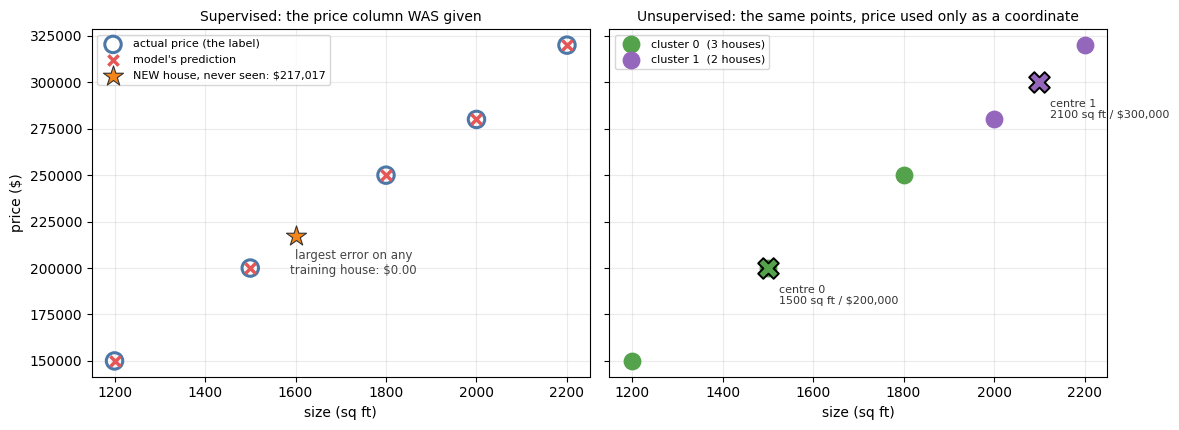

Training rows: 5    Model parameters: 6 coefficients + 1 intercept = 7
Residual (actual - predicted) for each of the five houses: [0.0, 0.0, -0.0, -0.0, -0.0]
Largest absolute training error: $0.000000
Cluster sizes: [3, 2]


In [6]:
# 📊 FIGURE — the same five houses, drawn twice: with the labels and without them.
# WHAT: no new model is fitted. We plot the objects already sitting in memory —
#       `y` (the real prices), `predictions` (what the regression said), `predicted_price`
#       (the new 1600 sq ft house) and `kmeans` (the clusters found without labels).
# WHY: the Discuss box below claims this model reproduced its training data exactly.
#      A number can hint at that; a picture settles it.
import numpy as np
import matplotlib.pyplot as plt

sizes = df['size_sqft'].values
prices = y.values
residuals = prices - predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

# --- LEFT: supervised — the labels were given -------------------------------
ax1.scatter(sizes, prices, s=140, facecolor="none", edgecolor="#4C78A8", lw=2.2,
            label="actual price (the label)", zorder=3)
ax1.scatter(sizes, predictions, s=55, color="#E45756", marker="x", lw=2.5,
            label="model's prediction", zorder=4)
ax1.scatter([1600], predicted_price, s=230, marker="*", color="#F58518",
            edgecolor="#333", lw=0.8, zorder=5,
            label=f"NEW house, never seen: ${predicted_price[0]:,.0f}")
ax1.annotate(f"largest error on any\ntraining house: ${np.abs(residuals).max():,.2f}",
             (sizes.mean(), prices.mean()), textcoords="offset points",
             xytext=(-4, -58), fontsize=8.5, ha="center", color="#444")
ax1.set_xlabel("size (sq ft)"); ax1.set_ylabel("price ($)")
ax1.set_title("Supervised: the price column WAS given", fontsize=10)
ax1.legend(fontsize=8, loc="upper left"); ax1.grid(alpha=0.25)

# --- RIGHT: unsupervised — the same points, labels withheld -----------------
colours = ["#54A24B", "#9467BD"]
for k in range(kmeans.n_clusters):
    sel = clusters == k
    ax2.scatter(sizes[sel], prices[sel], s=140, color=colours[k], zorder=3,
                label=f"cluster {k}  ({sel.sum()} houses)")
for k, centre in enumerate(kmeans.cluster_centers_):
    ax2.scatter(centre[0], centre[1], marker="X", s=220, color=colours[k],
                edgecolor="black", lw=1.4, zorder=4)
    ax2.annotate(f"centre {k}\n{centre[0]:.0f} sq ft / ${centre[1]:,.0f}",
                 (centre[0], centre[1]), textcoords="offset points", xytext=(8, -26),
                 fontsize=8, color="#333")
ax2.set_xlabel("size (sq ft)")
ax2.set_title("Unsupervised: the same points, price used only as a coordinate",
              fontsize=10)
ax2.legend(fontsize=8, loc="upper left"); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Training rows: {len(prices)}    Model parameters: "
      f"{len(model.coef_)} coefficients + 1 intercept = {len(model.coef_) + 1}")
print(f"Residual (actual - predicted) for each of the five houses: "
      f"{np.round(residuals, 6).tolist()}")
print(f"Largest absolute training error: ${np.abs(residuals).max():,.6f}")
print(f"Cluster sizes: {np.bincount(clusters).tolist()}")

### 👁️ Read the figure

**Left — the red crosses are sitting inside the blue circles.** Every one of them.
The largest error the model makes on any training house is **exactly $0.00**
(printed under the plot), because the fit has **7 free parameters and 5 rows** to
satisfy — more knobs than data points, so a perfect pass through every point is
guaranteed rather than earned. This is the visual form of the printout the Discuss
box asks you about: *a model that scores perfectly on its training data has told
you nothing about whether it works.*

The orange star is the only genuinely interesting point on the panel — the 1600
sq ft house nobody has priced. Notice it is the one point with no blue circle
behind it: **there is nothing here to check it against.** Every other point on
this panel was used to build the line that produced it.

**Right — the same five dots, with the price column demoted.** K-Means was never
told what "price" means; it treated it as a second coordinate and split the houses
into a cheap-small group and an expensive-large one. The two black X marks are the
cluster centres, the "average house" of each group — and they are the *only* thing
the unsupervised run can give you. Ask it what the new 1600 sq ft house costs and
it has no answer, because it never had a price to learn from.

**What this proves:** the label is what decides which questions a model can answer,
not how clever the algorithm is. Same data, same five points, same plot — one
panel can price a house it has never seen, and the other cannot. And the panel
that can price it is the one you should trust least here, for the reason the left
panel makes impossible to miss.

## ⚠️ Where this breaks

**This notebook's own model is the clearest example.** Five houses, six features,
a perfect fit and a negative bedroom coefficient. That is not a linear regression
that learned about housing; it is a linear regression with enough freedom to
interpolate five points. Read it as a demonstration of the *API*, never as a
result about prices.

- **No held-out data means no evidence.** Nothing here was evaluated on a house
  the model had not seen, so the notebook contains zero information about how it
  generalises. From notebook 06 onward every model in this course is scored on a
  test set, and that is not a formality.
- **More parameters than rows is always a perfect fit.** With *n* data points and
  ≥ *n* free parameters, a perfect training score is guaranteed and meaningless.
  Watch for it whenever a result looks too clean.
- **K-Means was told to find two clusters.** `n_clusters=2` was our choice, not a
  discovery. Ask for three and you will get three, on the same five houses. An
  unsupervised algorithm cannot tell you that the number you asked for is wrong —
  you need a separate criterion, and Course 04 covers the ones that exist.
- **The taxonomy has soft edges.** Self-supervised learning (how every modern
  language model is trained) invents its own labels from unlabelled text, and
  semi-supervised learning mixes both. The three-way split below is a good first
  map, not a partition of the world.
- **The paradigm does not choose itself.** "We have a lot of data" is not a
  reason to do machine learning. If the rule is known and stable — a tax band, a
  safety threshold, an eligibility regulation — write the rule. Learning it from
  data adds error, cost and an explanation problem, and buys nothing.


## 🔭 State of the field (2026)

The taxonomy above — supervised, unsupervised, reinforcement — is intact, but the default *workflow*
underneath it moved. In 2026 the first step on a new tabular problem is often not "fit a model to this
dataset" but "condition a pretrained model on it": tabular foundation models take your labelled rows
as in-context examples and predict without a per-dataset training run, and the current release of that
line reports beating tuned tree ensembles on small and medium tables (Grinsztajn et al., 2025). The
same shift happened in language, where one open model family now ships deliberate reasoning as a mode
you switch on rather than as a separately trained system (Yang et al., 2025).

None of that removes anything on this page. You still need features and labels, a train/test split,
and the habit of asking what the model was actually given — five houses and six features is too little
evidence for any method, fitted or conditioned, and you can only *see* that because you know what
fitting is. Treat the foundation-model route as one more baseline you are obliged to beat, and keep
the taxonomy: it is how you decide which of the three problems you are even solving.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. Samuel, A. L. (1959). *Some Studies in Machine Learning Using the Game of Checkers*. IBM Journal of Research and Development, 3(3), 210–229.
2. Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 2: Statistical Learning. Springer.
4. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2511.08667>
5. Yang, A., Li, A., Yang, B., et al. (2025). *Qwen3 Technical Report*. arXiv. <https://arxiv.org/abs/2505.09388>